In [1]:
from pathlib import Path
import sys
import logging

logger = logging.getLogger(__name__)
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from src.eda import (
    get_dataset_info,
    label_distribution,
    group_by_label,
    date_range,
    get_missing_summary,
    get_column_types,
    get_numeric_statistics,
    get_skewness,
    get_outlier_summary,
    find_negative_values,
    get_categorical_summary,
    get_category_counts,
    get_rare_categories,
    compare_normalized_categories,
    get_numeric_label_summary,
    get_state_late_rate,
    get_payment_late_rate,
    get_payment_crosstab,
    get_correlation_with_target,
    get_orders_over_time,
    get_late_rate_over_time,
    get_weekday_late_rate,
    get_month_late_rate,
    add_delivery_days,
    get_delivery_days_by_label,
    get_customer_state_summary,
    create_geo_by_zip,
    create_seller_order_data,
    get_seller_statistics,
    get_seller_state_late_rate,
    calculate_order_distances,
)

In [5]:
import yaml

with open(
    PROJECT_ROOT / "config" / "config.yaml",
    "r",
    encoding="utf-8",
) as file:
    config = yaml.safe_load(file)

train_path = (
    PROJECT_ROOT
    / config["paths"]["train"]
)

train_df = pd.read_csv(train_path)

logger.info("Train shape:%s", train_df.shape)

2026-09-21 15:27:10,373 - INFO - Train shape:(67533, 37)


In [6]:
eda_charts_path = PROJECT_ROOT / "eda_charts"

eda_charts_path.mkdir(
    parents=True,
    exist_ok=True,
)

logger.info("EDA charts folder ready.")

2026-09-21 15:27:14,405 - INFO - EDA charts folder ready.


In [7]:
info = get_dataset_info(train_df)

logger.info("Rows:%s", info["rows"])
logger.info("Columns:%s", info["columns"])
logger.info(
    f"Total memory usage:%s "
    f"{info['memory_mb']:.2f} MB"
)

2026-09-21 15:27:21,029 - INFO - Rows:67533
2026-09-21 15:27:21,031 - INFO - Columns:37
2026-09-21 15:27:21,035 - INFO - Total memory usage:%s 71.23 MB


In [8]:
train_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       67533 non-null  object 
 1   customer_id                    67533 non-null  object 
 2   order_status                   67533 non-null  object 
 3   order_purchase_timestamp       67533 non-null  object 
 4   order_approved_at              67522 non-null  object 
 5   order_delivered_carrier_date   67532 non-null  object 
 6   order_delivered_customer_date  67533 non-null  object 
 7   order_estimated_delivery_date  67533 non-null  object 
 8   customer_unique_id             67533 non-null  object 
 9   customer_zip_code_prefix       67533 non-null  int64  
 10  customer_city                  67533 non-null  object 
 11  customer_state                 67533 non-null  object 
 12  total_items                    67533 non-null 

In [9]:
missing_df = get_missing_summary(
    train_df
)

missing_df

,missing_count,missing_percentage
distance_km,323,0.478285
avg_volume,12,0.017769
max_volume,12,0.017769
order_approved_at,11,0.016288
order_delivered_carrier_date,1,0.001481


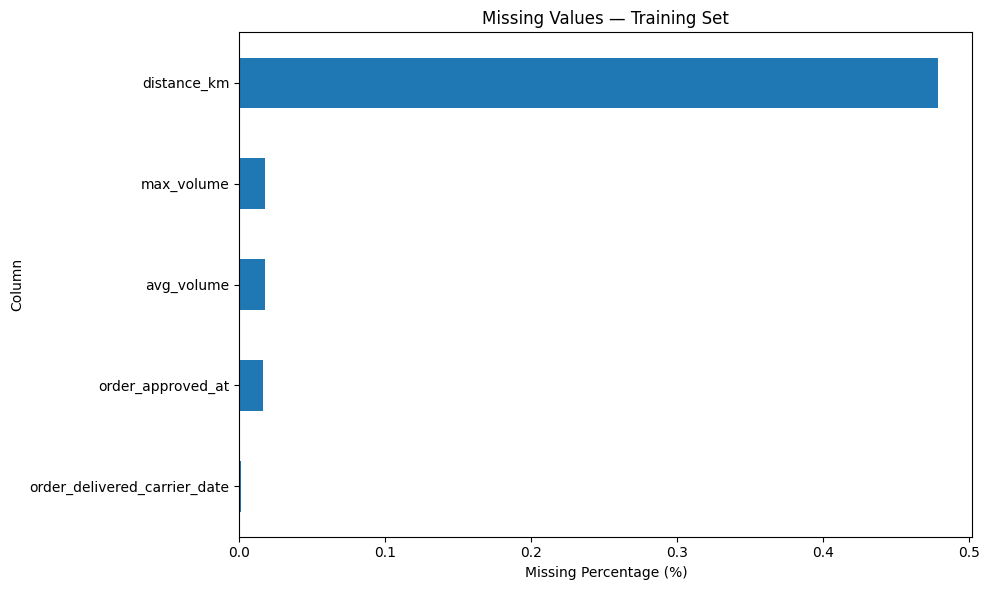

In [10]:
plt.figure(figsize=(10, 6))

missing_df[
    "missing_percentage"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Missing Values — Training Set"
)
plt.xlabel(
    "Missing Percentage (%)"
)
plt.ylabel("Column")
plt.tight_layout()

plt.savefig(
    eda_charts_path
    / "02_missing_values.png",
    dpi=150,
)

plt.show()

In [11]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    if col in train_df.columns:
        train_df[col] = pd.to_datetime(
            train_df[col],
            errors="coerce",
        )

In [12]:
id_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
]

categorical_columns = [
    "order_status",
    "customer_city",
    "customer_state",
    "main_payment_type",
]

target_column = "is_late"

column_types = get_column_types(
    train_df,
    id_columns=id_columns,
    categorical_columns=categorical_columns,
    date_columns=date_columns,
    target_column=target_column,
)

numerical_columns = column_types["numerical"]

In [13]:
logger.info("ID columns:%s")
logger.info(id_columns)

logger.info("\nCategorical columns:%s")
logger.info(categorical_columns)

logger.info("\nDate columns:%s")
logger.info(date_columns)

logger.info("\nNumerical columns:%s")
logger.info(numerical_columns)

logger.info("\nTarget:%s")
logger.info(target_column)

2026-09-21 15:28:02,558 - INFO - ID columns:%s
2026-09-21 15:28:02,561 - INFO - ['order_id', 'customer_id', 'customer_unique_id']
2026-09-21 15:28:02,565 - INFO - 
Categorical columns:%s
2026-09-21 15:28:02,569 - INFO - ['order_status', 'customer_city', 'customer_state', 'main_payment_type']
2026-09-21 15:28:02,651 - INFO - 
Date columns:%s
2026-09-21 15:28:02,655 - INFO - ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
2026-09-21 15:28:02,660 - INFO - 
Numerical columns:%s
2026-09-21 15:28:02,663 - INFO - ['customer_zip_code_prefix', 'total_items', 'total_price', 'total_freight_value', 'avg_item_price', 'total_payment_value', 'max_installments', 'payment_count', 'unique_products', 'unique_sellers', 'purchase_month', 'purchase_day', 'purchase_weekday', 'purchase_hour', 'is_weekend', 'multi_seller', 'freight_ratio', 'freight_per_item', 'total_weight', 'total_volume', 'avg_volume', 'max_vo

In [14]:
numeric_stats = get_numeric_statistics(
    train_df,
    numerical_columns,
)

numeric_stats

,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,67533.0,35123.193535,29794.171703,1003.00,11346.000000,24422.000000,58890.000000,9.996500e+04
total_items,67533.0,1.140405,0.534797,1.00,1.000000,1.000000,1.000000,2.000000e+01
total_price,67533.0,137.038885,211.187355,0.85,45.900000,85.990000,149.900000,1.344000e+04
total_freight_value,67533.0,22.766388,21.035570,0.00,13.860000,17.160000,23.960000,1.002290e+03
avg_item_price,67533.0,125.489584,191.962411,0.85,41.800000,79.000000,139.890000,6.735000e+03
total_payment_value,67533.0,159.837306,220.846508,9.59,61.790000,105.080000,175.770000,1.366408e+04
max_installments,67533.0,2.931589,2.718086,0.00,1.000000,2.000000,4.000000,2.400000e+01
payment_count,67533.0,1.043594,0.358134,1.00,1.000000,1.000000,1.000000,2.200000e+01
unique_products,67533.0,1.038159,0.227548,1.00,1.000000,1.000000,1.000000,8.000000e+00
unique_sellers,67533.0,1.013549,0.122088,1.00,1.000000,1.000000,1.000000,5.000000e+00


In [15]:
skewness = get_skewness(
    train_df,
    numerical_columns,
)

skewness

payment_count               20.679164
total_price                 10.456227
unique_sellers              10.138404
total_payment_value          9.893617
multi_seller                 8.634315
unique_products              8.228609
freight_ratio                8.105251
avg_item_price               7.956515
total_freight_value          7.748607
total_volume                 7.369025
total_items                  7.244315
total_weight                 6.253384
freight_per_item             5.649865
avg_volume                   4.110230
max_volume                   4.093231
distance_km                  1.703884
max_installments             1.610912
is_weekend                   1.292826
customer_zip_code_prefix     0.780558
purchase_month               0.202754
purchase_weekday             0.167964
purchase_day                 0.016940
is_cross_state              -0.591251
purchase_hour               -0.607518
dtype: float64

In [16]:
high_skew = skewness[
    skewness.abs() > 1
]

logger.info(
    "Highly skewed numerical features:%s"
)

logger.info(high_skew)

2026-09-21 15:28:10,860 - INFO - Highly skewed numerical features:%s
2026-09-21 15:28:10,863 - INFO - payment_count          20.679164
total_price            10.456227
unique_sellers         10.138404
total_payment_value     9.893617
multi_seller            8.634315
unique_products         8.228609
freight_ratio           8.105251
avg_item_price          7.956515
total_freight_value     7.748607
total_volume            7.369025
total_items             7.244315
total_weight            6.253384
freight_per_item        5.649865
avg_volume              4.110230
max_volume              4.093231
distance_km             1.703884
max_installments        1.610912
is_weekend              1.292826
dtype: float64


In [17]:
outlier_df = get_outlier_summary(
    train_df,
    numerical_columns,
)

outlier_df

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
14,is_weekend,0.000000,0.000000,15436,22.856974
18,total_weight,-2325.000000,4675.000000,9456,14.002043
17,freight_per_item,1.700000,32.820000,7344,10.874683
3,total_freight_value,-1.290000,39.110000,6831,10.115055
1,total_items,1.000000,1.000000,6637,9.827788
19,total_volume,-22275.000000,45045.000000,6257,9.265100
20,avg_volume,-20148.000000,41180.000000,5995,8.878719
21,max_volume,-20724.000000,42156.000000,5936,8.791339
2,total_price,-110.100000,305.900000,5374,7.957591
5,total_payment_value,-109.180000,346.740000,5357,7.932418


In [18]:
negative_values = find_negative_values(
    train_df,
    numerical_columns,
)

for col, count in negative_values.items():
    logger.info(
        f"{col}: {count} negative values"
    )

In [19]:
categorical_summary = (
    get_categorical_summary(
        train_df,
        categorical_columns,
    )
)

categorical_summary

,feature,unique_values,missing
0,order_status,2,0
1,customer_city,3650,0
2,customer_state,27,0
3,main_payment_type,4,0


In [21]:
category_counts = get_category_counts(
    train_df,
    categorical_columns,
    top_n=20,
)

for col, counts in category_counts.items():
    logger.info("\n" + "=" * 60)
    logger.info(col)
    logger.info("=" * 60)
    logger.info(counts)

2026-09-21 15:28:57,666 - INFO - 
2026-09-21 15:28:57,668 - INFO - order_status
2026-09-21 15:28:57,670 - INFO - ============================================================
2026-09-21 15:28:57,674 - INFO - order_status
delivered    67529
canceled         4
Name: count, dtype: int64
2026-09-21 15:28:57,678 - INFO - 
2026-09-21 15:28:57,681 - INFO - customer_city
2026-09-21 15:28:57,684 - INFO - ============================================================
2026-09-21 15:28:57,686 - INFO - customer_city
sao paulo                10555
rio de janeiro            4647
belo horizonte            1915
brasilia                  1438
curitiba                  1068
campinas                  1011
porto alegre               932
salvador                   833
guarulhos                  813
sao bernardo do campo      645
santo andre                560
niteroi                    559
santos                     500
osasco                     489
goiania                    471
sao jose dos campos        45

In [22]:
rare_categories = get_rare_categories(
    train_df,
    categorical_columns,
    threshold=1.0,
)

for col, rare in rare_categories.items():
    logger.info
    (
        f"\n{col}: {len(rare)} rare categories"
    )

In [23]:
normalized_summary = (
    compare_normalized_categories(
        train_df,
        categorical_columns,
    )
)

normalized_summary

,feature,original_unique,normalized_unique
0,order_status,2,2
1,customer_city,3650,3650
2,customer_state,27,27
3,main_payment_type,4,4


In [24]:
numeric_label_summary = (
    get_numeric_label_summary(
        train_df,
        numerical_columns,
        target_column,
    )
)

numeric_label_summary

,On_Time,Late
customer_zip_code_prefix,34918.199181,37444.916408
total_items,1.143665,1.103486
total_price,136.020077,148.577689
total_freight_value,22.606489,24.577374
avg_item_price,124.217570,139.896137
total_payment_value,158.659220,173.180057
max_installments,2.925549,3.000000
payment_count,1.044510,1.033218
unique_products,1.039885,1.018617
unique_sellers,1.014632,1.001278


In [25]:
state_late_rate = get_state_late_rate(
    train_df
)

state_late_rate

customer_state
AL    24.163569
MA    19.721116
RR    16.666667
PI    16.216216
CE    15.955056
SE    15.637860
BA    13.997367
RJ    13.598520
ES    12.265512
MS    12.000000
PA    11.901306
TO    11.794872
PB    11.653117
PE    10.976744
RN    10.495627
SC     9.003752
GO     7.976795
DF     7.409972
RS     6.982343
MT     6.879195
AP     6.666667
SP     5.856237
MG     5.715712
PR     5.220884
AM     4.761905
AC     3.636364
RO     3.468208
Name: is_late, dtype: float64

In [26]:
payment_late_rate = get_payment_late_rate(
    train_df
)

payment_late_rate

,mean,count,late_percentage
main_payment_type,,,
boleto,0.088400,13405,8.839985
credit_card,0.079685,51779,7.968481
debit_card,0.074928,1041,7.492795
voucher,0.068807,1308,6.880734


In [27]:
payment_crosstab = get_payment_crosstab(
    train_df
)

payment_crosstab

is_late,0,1
main_payment_type,,
boleto,12220,1185
credit_card,47653,4126
debit_card,963,78
voucher,1218,90


In [28]:
correlation_with_target = (
    get_correlation_with_target(
        train_df,
        numerical_columns,
        target_column,
    )
)

correlation_with_target

multi_seller               -0.030601
unique_sellers             -0.029867
purchase_month             -0.028730
unique_products            -0.025520
total_items                -0.020513
purchase_weekday           -0.012373
is_weekend                 -0.009213
payment_count              -0.008609
freight_ratio               0.004771
purchase_hour               0.004969
purchase_day                0.006107
max_installments            0.007479
total_volume                0.009450
total_weight                0.014932
total_price                 0.016235
max_volume                  0.017496
total_payment_value         0.017952
avg_volume                  0.019042
avg_item_price              0.022300
customer_zip_code_prefix    0.023155
total_freight_value         0.025582
freight_per_item            0.042814
is_cross_state              0.058349
distance_km                 0.071354
Name: is_late, dtype: float64

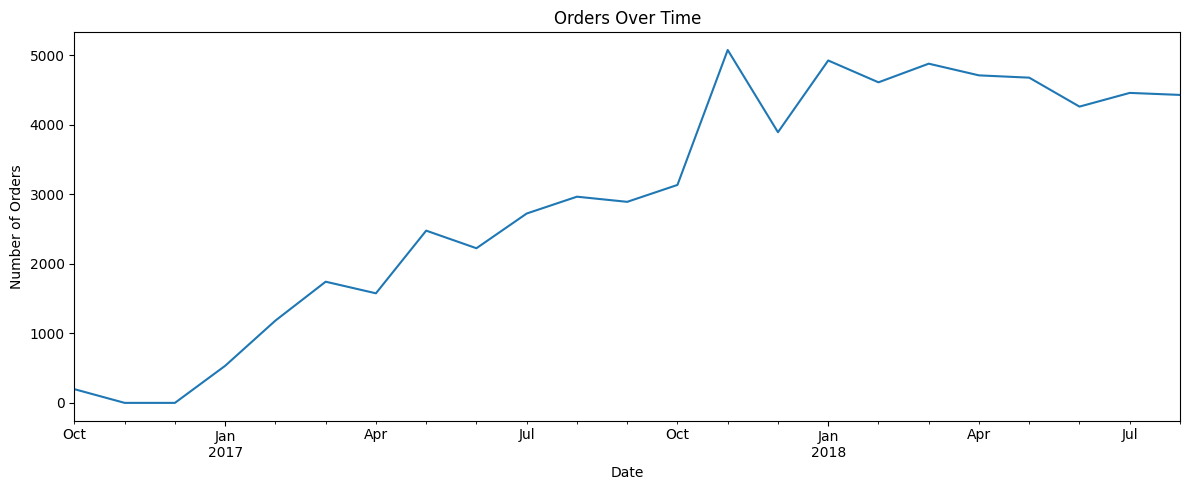

In [29]:
orders_by_date = get_orders_over_time(
    train_df
)

plt.figure(figsize=(12, 5))

orders_by_date.plot()

plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.tight_layout()

plt.savefig(
    eda_charts_path
    / "05_orders_over_time.png",
    dpi=150,
)

plt.show()

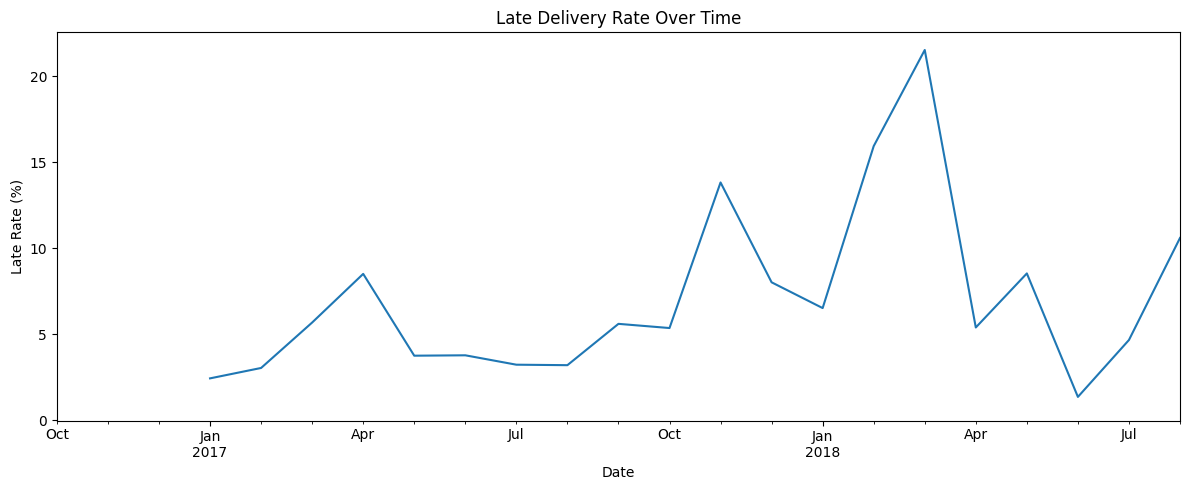

In [31]:
monthly_late_rate = (
    get_late_rate_over_time(train_df)
)

plt.figure(figsize=(12, 5))

monthly_late_rate.plot()

plt.title(
    "Late Delivery Rate Over Time"
)

plt.xlabel("Date")
plt.ylabel("Late Rate (%)")

plt.tight_layout()

plt.savefig(
    eda_charts_path
    / "06_late_rate_over_time.png",
    dpi=150,
)

plt.show()

In [32]:
weekday_late_rate = (
    get_weekday_late_rate(train_df)
)

weekday_late_rate

purchase_weekday
Monday       8.913803
Tuesday      8.598697
Wednesday    7.645173
Thursday     7.462835
Friday       8.588830
Saturday     7.598039
Sunday       7.698962
Name: is_late, dtype: float64

In [33]:
monthly_rate = (
    get_month_late_rate(train_df)
)

monthly_rate

purchase_month
1      6.122823
2     13.296495
3     17.346630
4      6.175394
5      6.880157
6      2.190682
7      4.123711
8      7.630902
9      5.605536
10     5.105105
11    13.818253
12     8.018504
Name: is_late, dtype: float64

In [34]:
train_df = add_delivery_days(
    train_df
)

In [35]:
get_delivery_days_by_label(
    train_df
)

,count,mean,std,min,25%,50%,75%,max
is_late,,,,,,,,
0,62054.0,10.868615,6.195280,0.533414,6.347555,9.710602,14.163194,70.213611
1,5479.0,31.429827,17.287311,2.129537,22.302274,29.043889,37.973872,209.628611


In [36]:
train_df = train_df.drop(
    columns=["delivery_days"],
    errors="ignore",
)

In [37]:
from src.data import (
    create_db_engine,
    load_table,
)

In [38]:
engine = create_db_engine(config)

In [39]:
order_items = load_table(
    engine,
    "order_items",
)

sellers = load_table(
    engine,
    "sellers",
)

geolocation = load_table(
    engine,
    "geolocation",
)

In [40]:
seller_order_data = create_seller_order_data(
    order_items,
    sellers,
)

In [50]:
seller_stats = get_seller_statistics(
    seller_order_data,
    sellers,
)

logger.info(
    "Orders with multiple sellers:%s",
    seller_stats[
        "orders_with_multiple_sellers"
    ],
)

logger.info(
    "\nMaximum sellers in one order:%s",
    seller_stats[
        "maximum_sellers_per_order"
    ],
)

2026-09-21 15:34:11,716 - INFO - Orders with multiple sellers:1278
2026-09-21 15:34:11,865 - INFO - 
Maximum sellers in one order:5


In [52]:
seller_state_summary = (
    seller_stats[
        "orders_by_seller_state"
    ]
)

seller_state_summary

seller_state
SP    70188
MG     7930
PR     7673
RJ     4353
SC     3667
RS     1989
DF      824
BA      569
GO      463
PE      406
MA      392
ES      318
MT      137
CE       91
RN       51
MS       49
PB       36
RO       14
PI       12
SE        9
PA        8
AM        3
AC        1
Name: order_id, dtype: int64

In [53]:
seller_state_count = (
    seller_stats["sellers_by_state"]
)

seller_state_count

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
AM       1
MA       1
PA       1
Name: seller_id, dtype: int64

In [54]:
seller_state_late_rate = (
    get_seller_state_late_rate(
        seller_order_data,
        train_df,
    )
)

seller_state_late_rate

seller_state
AM    66.666667
MA    24.054983
RJ     8.519767
SP     8.434240
MS     8.333333
RN     7.692308
DF     7.679739
ES     6.746032
PB     6.451613
PR     6.353683
SC     6.184448
CE     6.060606
MG     5.355662
BA     5.092593
MT     4.629630
PE     4.276316
RS     4.273504
GO     3.542234
PA     0.000000
RO     0.000000
SE     0.000000
PI     0.000000
Name: is_late, dtype: float64

In [55]:
geo_by_zip = create_geo_by_zip(
    geolocation
)

logger.info(
    "Unique ZIP prefixes:%s",
    geo_by_zip[
        "geolocation_zip_code_prefix"
    ].nunique(),
)

2026-09-21 15:34:37,339 - INFO - Unique ZIP prefixes:19015


In [46]:
geo_orders, distance_by_order = (
    calculate_order_distances(
        train_df,
        seller_order_data,
        geo_by_zip,
    )
)

In [47]:
distance_by_order.groupby(
    "is_late"
)["distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
is_late,,,,,,,,
0,61769.0,588.439101,582.769628,0.0,177.485569,425.951999,784.803877,5338.619521
1,5441.0,743.965578,698.511055,0.0,296.199566,510.990239,932.568484,8677.911622


In [56]:
logger.info(
    "Correlation between distance "
    "and is_late:%s",
    distance_by_order[
        ["distance_km", "is_late"]
    ]
    .corr()
    .loc["distance_km", "is_late"],
)

2026-09-21 15:34:48,119 - INFO - Correlation between distance and is_late:0.07135981096421184


In [ ]:
train_df = train_df.drop(
    columns=[
        "purchase_weekday",
        "purchase_month",
        "delivery_days",
    ],
    errors="ignore",
)

In [73]:
# chart_output_path = PROJECT_ROOT / config["paths"]["eda_charts"]
# chart_output_path.parent.mkdir(parents=True,exist_ok=True)
# df_dist = label_distribution(train_df,target_column="is_late") * 100
# plt.figure(figsize=(8,5))

# ax = df_dist.plot(kind='bar',stacked=True,edgecolor='black',ax=plt.gca())
# plt.title("Label Distribution")
# plt.xlabel('Labels')
# plt.ylabel('Count')
# plt.ylim(0,100)
# plt.xticks(rotation=0)
# plt.legend(title="is_late Status",bbox_to_anchor=(1.05,1),loc='upper left')
# plt.savefig(chart_output_path,bbox_inches='tight',dpi=300)
# plt.show()

# logger.info("Saved is Successful!")